In [3]:
!pip install -q ultralytics opencv-python numpy matplotlib pandas filterpy

In [4]:
import os, sys, json, csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from filterpy.kalman import KalmanFilter

In [5]:
DATASET_INPUT = Path("/kaggle/input/datasets/abhijeetkc00/padeltracker100")
WORK_DIR = Path("/kaggle/working")
OUTPUT_DIR = WORK_DIR / "padel_pipeline"
IMAGES_DIR = OUTPUT_DIR / "yolo" / "images"
LABELS_DIR = OUTPUT_DIR / "yolo" / "labels"
MODEL_DIR = OUTPUT_DIR / "models"
ANALYTICS_DIR = OUTPUT_DIR / "analytics"
VIDEOS_DIR = OUTPUT_DIR / "videos"

FRAME_INTERVAL = 5        # take every 5th frame (balance speed / dataset size)
YOLO_IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS_STAGE1 = 30        # player+ball only
DEVICE = "cuda"          # or "cpu"

In [6]:
# Create folder structure
for d in [WORK_DIR, IMAGES_DIR / "train", IMAGES_DIR / "val",
          LABELS_DIR / "train", LABELS_DIR / "val",
          MODEL_DIR, ANALYTICS_DIR, VIDEOS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [7]:
# ## 1. Extract frames from the two full match videos

# %% [code]
video_names = [
    ("2022_BCN_FinalF_1.mp4", "FinalF"),
    ("2022_BCN_FinalM_1.mp4", "FinalM")
]
target_fps = None   # keep original fps
frame_counts = {"train": 0, "val": 0}

def extract_frames(video_path, match_id):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Processing {match_id} – {total_frames} frames at {fps:.1f} FPS")
    
    idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if idx % FRAME_INTERVAL == 0:
            # split 80/20 train/val
            split = "train" if idx < total_frames * 0.8 else "val"
            img_name = f"{match_id}_{idx:07d}.jpg"
            cv2.imwrite(str(IMAGES_DIR / split / img_name), frame)
            frame_counts[split] += 1
        idx += 1
    cap.release()
    return total_frames

for video_file, match_id in video_names:
    vid_path = DATASET_INPUT / video_file
    if vid_path.exists():
        extract_frames(vid_path, match_id)
    else:
        print(f"WARNING: {vid_path} not found. Skipping.")
        
print(f"Extracted: train={frame_counts['train']}, val={frame_counts['val']}")


Processing FinalF – 45934 frames at 30.0 FPS
Processing FinalM – 53953 frames at 30.0 FPS
Extracted: train=15983, val=3995


In [8]:
import json

pose_path = DATASET_INPUT / "labels" / "2022_BCN_FinalF_1_pose.json"
with open(pose_path) as f:
    pose = json.load(f)

# Images
imgs = pose['images']
print("Type of imgs:", type(imgs))
print("First element type:", type(imgs[0]))
print("First element content:", imgs[0][:3] if isinstance(imgs[0], list) else imgs[0])
print("Number of images:", len(imgs))

# Annotations
anns = pose['annotations']
print("\nType of anns:", type(anns))
print("First annotation:", anns[0] if anns else "No annotations")
print("Number of annotations:", len(anns))

# Categories
print("\nCategories:", pose['categories'])

Type of imgs: <class 'list'>
First element type: <class 'dict'>
First element content: {'id': 1, 'width': 1920, 'height': 1080, 'file_name': 'frame_000000.PNG', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
Number of images: 45934

Type of anns: <class 'list'>
First annotation: {'id': 1, 'image_id': 1, 'category_id': 1, 'segmentation': [], 'area': 5040.7029999999995, 'bbox': [793.57, 248.02, 46.63, 108.1], 'iscrowd': 0, 'attributes': {'occluded': False, 'keyframe': False}, 'keypoints': [823.8, 257.87, 2, 823.95, 254.33, 2, 821.76, 254.83, 2, 809.29, 251.63, 2, 814.68, 253.15, 2, 802.09, 262.54, 2, 811.71, 268.32, 2, 793.57, 257.2, 2, 825.24, 282.95, 2, 802.53, 248.02, 2, 840.2, 296.43, 2, 797.46, 296.84, 2, 803.59, 298.81, 2, 807.8, 323.9, 2, 810.4, 326.03, 2, 803.67, 347.2, 2, 809.68, 356.12, 2], 'num_keypoints': 17}
Number of annotations: 183744

Categories: [{'id': 1, 'name': 'person', 'supercategory': '', 'keypoints': ['nose', 'left_eye', 'right_eye', 'left_ea

In [9]:
# =============================================
# 2. Parse annotations and create YOLO labels (FIXED)
# =============================================

import json
from collections import defaultdict
from pathlib import Path

# ---------- COCO loader ----------
def load_coco(path):
    with open(path) as f:
        return json.load(f)

def parse_coco_bboxes(coco_dict, cls_mapping):
    """
    Returns dict: image_id -> list of (class_id, xc, yc, w, h, visible)
    visible is True by default, overridden if annotation has a 'visible' attribute.
    """
    images = coco_dict['images']
    anns_by_image = defaultdict(list)
    
    # Build image info
    img_info = {img['id']: img for img in images}
    
    for ann in coco_dict['annotations']:
        img_id = ann['image_id']
        cat_id = ann['category_id']
        if cat_id not in cls_mapping:
            continue
        cls = cls_mapping[cat_id]
        
        bbox = ann['bbox']  # [x, y, w, h]
        x, y, w, h = bbox
        
        # Determine visibility (ball may have this)
        visibility = True
        attrs = ann.get('attributes', {})
        if 'visible' in attrs:
            visibility = attrs['visible']
        elif 'visible' in ann:
            visibility = ann['visible']
        
        # Normalize
        iw = img_info[img_id]['width']
        ih = img_info[img_id]['height']
        xc = (x + w / 2) / iw
        yc = (y + h / 2) / ih
        bw = w / iw
        bh = h / ih
        
        anns_by_image[img_id].append((cls, xc, yc, bw, bh, visibility))
    
    return anns_by_image

# ---------- Specific mappings ----------
POSE_CLASS_MAP = {1: 0}    # 'person' -> class 0
BALL_CLASS_MAP = {1: 1}    # ball -> class 1 (assuming ball cat_id 1 in ball JSON)

# ---------- Process both matches ----------
match_configs = [
    {
        'match_id': 'FinalF',
        'pose_json': '2022_BCN_FinalF_1_pose.json',
        'ball_json': '2022_BCN_FinalF_1_ball.json'
    },
    {
        'match_id': 'FinalM',
        'pose_json': '2022_BCN_FinalM_1_pose.json',
        'ball_json': '2022_BCN_FinalM_1_ball.json'
    }
]

# Combine all bboxes by (match_id, frame_idx)
all_pose_bboxes = {}  # key: (match_id, frame_idx) -> list of bbox tuples
all_ball_bboxes = {}

for cfg in match_configs:
    match = cfg['match_id']
    # Load pose
    pose_path = DATASET_INPUT / "labels" / cfg['pose_json']
    if not pose_path.exists():
        print(f"Missing {pose_path}")
        continue
    pose_coco = load_coco(pose_path)
    pose_dict = parse_coco_bboxes(pose_coco, POSE_CLASS_MAP)
    
    # Load ball
    ball_path = DATASET_INPUT / "labels" / cfg['ball_json']
    if not ball_path.exists():
        print(f"Missing {ball_path}")
        ball_dict = {}
    else:
        ball_coco = load_coco(ball_path)
        ball_dict = parse_coco_bboxes(ball_coco, BALL_CLASS_MAP)
    
    # Convert image_id (1‑based) to frame_idx (0‑based) and store
    # We iterate over all image_ids present in pose_dict (ball might have fewer)
    all_img_ids = set(pose_dict.keys()) | set(ball_dict.keys())
    for img_id in all_img_ids:
        frame_idx = img_id - 1
        key = (match, frame_idx)
        all_pose_bboxes[key] = pose_dict.get(img_id, [])
        all_ball_bboxes[key] = ball_dict.get(img_id, [])

# ---------- Generate .txt labels ----------
# (video dimensions known – 1920x1080, but normalization already done)
for split in ["train", "val"]:
    img_dir = IMAGES_DIR / split
    for img_name in tqdm(os.listdir(img_dir), desc=f"Creating {split} labels"):
        base = img_name.replace(".jpg", "")
        # parse "FinalF_0000123" or "FinalM_0000123"
        match_id, frame_str = base.split("_", 1)
        frame_idx = int(frame_str)
        
        label_path = LABELS_DIR / split / (base + ".txt")
        with open(label_path, "w") as out:
            # Players
            for (cls, xc, yc, bw, bh, vis) in all_pose_bboxes.get((match_id, frame_idx), []):
                out.write(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")
            # Ball (only if visible)
            for (cls, xc, yc, bw, bh, vis) in all_ball_bboxes.get((match_id, frame_idx), []):
                if vis:
                    out.write(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

print("Label generation complete.")

Creating val labels: 100%|██████████| 3995/3995 [00:00<00:00, 14494.48it/s]

Label generation complete.


In [10]:
# ## 3. Create dataset YAML and train YOLOv11

# %% [code]
# YAML config
yaml_content = f"""
train: {IMAGES_DIR / 'train'}
val: {IMAGES_DIR / 'val'}

nc: 2
names: ['player', 'ball']
"""
yaml_path = OUTPUT_DIR / "padel_data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

# %% [code]
from ultralytics import YOLO

model = YOLO("yolo11n.pt")   # nano version
results_stage1 = model.train(
    data=str(yaml_path),
    epochs=EPOCHS_STAGE1,
    imgsz=YOLO_IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    name="padel_stage1",
    exist_ok=True
)

# Save best weights explicitly
model.save(str(MODEL_DIR / "padel_player_ball.pt"))
print("Stage 1 training complete.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/padel_pipeline/padel_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

In [13]:
# Zip the folder
!zip -r /kaggle/working/padel_stage1.zip /kaggle/working/runs/detect/padel_stage1

# Download the zip file
from IPython.display import FileLink

FileLink('/kaggle/working/padel_stage1.zip')

  adding: kaggle/working/runs/detect/padel_stage1/ (stored 0%)
  adding: kaggle/working/runs/detect/padel_stage1/train_batch1.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/padel_stage1/train_batch2.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/padel_stage1/val_batch1_labels.jpg (deflated 12%)
  adding: kaggle/working/runs/detect/padel_stage1/train_batch19982.jpg (deflated 13%)
  adding: kaggle/working/runs/detect/padel_stage1/labels.jpg (deflated 41%)
  adding: kaggle/working/runs/detect/padel_stage1/train_batch19981.jpg (deflated 12%)
  adding: kaggle/working/runs/detect/padel_stage1/confusion_matrix.png (deflated 31%)
  adding: kaggle/working/runs/detect/padel_stage1/confusion_matrix_normalized.png (deflated 31%)
  adding: kaggle/working/runs/detect/padel_stage1/val_batch2_pred.jpg (deflated 11%)
  adding: kaggle/working/runs/detect/padel_stage1/BoxR_curve.png (deflated 14%)
  adding: kaggle/working/runs/detect/padel_stage1/BoxF1_curve.png (deflated 13%)
  adding: k

/kaggle/working/padel_stage1.zip

In [11]:
# ## 4. Kalman‑filter ball tracker & hit detection

# We'll set up a simple Kalman filter for ball position (x,y) with constant velocity model.
# Hit detection: sudden change in ball’s direction (> 60°).
# Bounce detection: ball y‑velocity changes sign while ball is near the floor.

# %% [code]
class BallTracker:
    def __init__(self, dt=1.0):
        self.kf = KalmanFilter(dim_x=4, dim_z=2)
        self.kf.F = np.array([[1, 0, dt, 0],
                              [0, 1, 0, dt],
                              [0, 0, 1,  0],
                              [0, 0, 0,  1]], dtype=float)
        self.kf.H = np.array([[1, 0, 0, 0],
                              [0, 1, 0, 0]], dtype=float)
        self.kf.P *= 1000
        self.kf.R = np.diag([5, 5])    # measurement noise (pixels)
        self.kf.Q = np.eye(4) * 0.1   # process noise
        self.initialized = False
        self.prev_velocity = None

    def update(self, detection=None):
        """If detection is None, only predict. Returns (x, y) estimate."""
        if not self.initialized and detection is not None:
            self.kf.x = np.array([[detection[0]], [detection[1]], [0], [0]])
            self.initialized = True
            return detection

        if detection is not None:
            self.kf.update(np.array(detection).reshape(2,1))
        self.kf.predict()
        x, y = self.kf.x[0,0], self.kf.x[1,0]
        return (x, y)

    @property
    def velocity(self):
        return (self.kf.x[2,0], self.kf.x[3,0])

def calculate_angle(v1, v2):
    """Angle between two vectors in degrees."""
    dot = v1[0]*v2[0] + v1[1]*v2[1]
    norm1 = np.sqrt(v1[0]**2 + v1[1]**2)
    norm2 = np.sqrt(v2[0]**2 + v2[1]**2)
    if norm1 == 0 or norm2 == 0:
        return 0
    cos = dot / (norm1 * norm2)
    cos = np.clip(cos, -1, 1)
    return np.degrees(np.arccos(cos))

class HitBounceDetector:
    def __init__(self, angle_thresh=60, floor_y_fraction=0.8, min_velocity=5):
        self.angle_thresh = angle_thresh
        self.floor_y_fraction = floor_y_fraction    # lower fraction means higher floor (0 = top, 1 = bottom)
        self.min_velocity = min_velocity
        self.prev_pos = None
        self.prev_velocity = None
        self.hits = []      # list of frame numbers
        self.bounces = []   # list of frame numbers

    def update(self, frame_num, ball_pos, frame_height):
        """Must be called every frame with ball position and frame height (for floor)."""
        if ball_pos is None:
            return
        if self.prev_pos is None:
            self.prev_pos = ball_pos
            return

        velocity = (ball_pos[0] - self.prev_pos[0], ball_pos[1] - self.prev_pos[1])
        # Detect hit: large angle change in velocity (only if speed > min_velocity)
        if self.prev_velocity is not None:
            speed = np.sqrt(velocity[0]**2 + velocity[1]**2)
            if speed > self.min_velocity:
                angle = calculate_angle(self.prev_velocity, velocity)
                if angle > self.angle_thresh:
                    self.hits.append(frame_num)
        # Detect bounce: y-velocity sign change while ball near floor
        if self.prev_velocity is not None and ball_pos is not None:
            floor_y = frame_height * self.floor_y_fraction
            if (self.prev_velocity[1] * velocity[1] < 0) and (ball_pos[1] > floor_y):
                self.bounces.append(frame_num)

        self.prev_velocity = velocity
        self.prev_pos = ball_pos

In [14]:
def get_iou(boxA, boxB):
    # box format: (x1, y1, x2, y2)
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

In [15]:
# %% [markdown]
# ## 5. Inference & shot classification

# We’ll use a simple pose heuristic for shot type:
# - Serve/Smash : wrist y < shoulder y (i.e. hand above shoulder)
# - Forehand/Backhand : determined by ball position relative to player’s spine (left/right)

# For pose extraction we can use YOLO‑pose model (yolo11n-pose.pt) – this runs in parallel with detection.
# We'll combine player detection boxes and pose keypoints.

# %% [code]
from ultralytics import YOLO

# Load the trained player+ball detector and a separate pose model
det_model = YOLO(str(MODEL_DIR / "padel_player_ball.pt"))
pose_model = YOLO("yolo11n-pose.pt")   # pretrained on COCO for person keypoints

# Prepare video input and output
test_video = DATASET_INPUT / "2022_BCN_FinalF_1_sample.mp4"   # sample video for demo
if not test_video.exists():
    # fallback to one of the full videos (first 1000 frames)
    test_video = DATASET_INPUT / "2022_BCN_FinalF_1.mp4"
    
cap = cv2.VideoCapture(str(test_video))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames_vid = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Prepare output video
out_video_path = VIDEOS_DIR / "annotated_output.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(out_video_path), fourcc, fps, (width, height))

# Initialise trackers
ball_tracker = BallTracker(dt=1/fps)
hit_bounce_detector = HitBounceDetector(angle_thresh=45, floor_y_fraction=0.8, min_velocity=3)

# Store analytics
shots_log = []   # each entry: {frame, timestamp, shot_type, player, ball_pos, direction, bounce}
frame_num = 0
last_hit_frame = -30  # to avoid multiple triggers for same hit

# For simplicity, we assign player IDs based on detection index (0 or 1)
# In a real system you'd use tracking (DeepSORT), but here we just label A/B based on x position.
def assign_player_id(det_box):
    """Return 'Player_A' if centre x < half width, else 'Player_B'."""
    x_center = (det_box[0] + det_box[2]) / 2
    if x_center < width/2:
        return "Player_A"
    else:
        return "Player_B"

# Direction logic (shorthand)
def get_direction(dx, dy, threshold=30):
    """Convert velocity vector to direction label."""
    if abs(dx) < threshold and abs(dy) < threshold:
        return "stationary"
    if abs(dx) > abs(dy):
        return "right" if dx > 0 else "left"
    else:
        return "down" if dy > 0 else "up"

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Detection on current frame
    det_results = det_model(frame, verbose=False)
    # Pose estimation for all persons in frame (independent of our detector)
    pose_results = pose_model(frame, verbose=False)

    # Extract player detections (class 0)
    player_boxes = []
    ball_pos = None
    for box in det_results[0].boxes:
        cls = int(box.cls)
        if cls == 0:   # player
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            player_boxes.append((x1, y1, x2, y2, box.conf))
        elif cls == 1: # ball
            xc, yc = box.xywh[0][:2].tolist()
            ball_pos = (xc, yc)

    # ---------- Kalman filter update ----------
    smooth_ball = ball_tracker.update(ball_pos)
    # Hit/bounce detection on smoothed position
    hit_bounce_detector.update(frame_num, smooth_ball, height)

    # ---------- Draw detections ----------
    for x1, y1, x2, y2, conf in player_boxes:
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
        player_id = assign_player_id((x1, y1, x2, y2))
        cv2.putText(frame, player_id, (int(x1), int(y1)-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    if smooth_ball is not None:
        cv2.circle(frame, (int(smooth_ball[0]), int(smooth_ball[1])), 6, (0,0,255), -1)
        cv2.putText(frame, "ball", (int(smooth_ball[0])+10, int(smooth_ball[1])), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    # ---------- Hit triggered -> shot classification ----------
    if frame_num in hit_bounce_detector.hits and (frame_num - last_hit_frame) > 10:
        last_hit_frame = frame_num
        # Find closest player to ball position at hit moment
        if ball_pos is None:
            ball_pos = smooth_ball  # use smoothed if raw not available
        closest_player = None
        min_dist = float('inf')
        closest_box = None
        for bx in player_boxes:
            x1, y1, x2, y2, _ = bx
            cx, cy = (x1+x2)/2, (y1+y2)/2
            dist = np.sqrt((cx-ball_pos[0])**2 + (cy-ball_pos[1])**2)
            if dist < min_dist:
                min_dist = dist
                closest_player = assign_player_id(bx)
                closest_box = bx

        # Shot type using pose keypoints (from YOLO‑pose)
        shot_type = "unknown"
        if pose_results[0].keypoints is not None and closest_box is not None:
            # Get keypoints for the closest player
            # For simplicity, we take the first person keypoints (if only one visible) or try to match by bbox
            # In a match, there are two players; we can match the closest box with pose detection using IoU.
            # We'll implement a rough matching: find pose whose bounding box overlaps most with closest_box.
            best_iou = 0
            best_kpts = None
            for idx, kpts in enumerate(pose_results[0].keypoints):
                # YOLO‑pose also provides boxes for each person
                if pose_results[0].boxes is None:
                    continue
                pbox = pose_results[0].boxes[idx]
                x1p, y1p, x2p, y2p = pbox.xyxy[0].tolist()
                # compute IoU with closest_box
                iou = get_iou(closest_box, (x1p, y1p, x2p, y2p))
                if iou > best_iou:
                    best_iou = iou
                    best_kpts = kpts
            if best_kpts is not None:
                # Keypoint indices (COCO): 5 left_shoulder, 6 right_shoulder, 9 left_wrist, 10 right_wrist
                # We'll check if any wrist is above its shoulder -> serve/smash
                try:
                    l_shoulder = best_kpts[5].numpy()
                    r_shoulder = best_kpts[6].numpy()
                    l_wrist = best_kpts[9].numpy()
                    r_wrist = best_kpts[10].numpy()
                except:
                    l_shoulder = r_shoulder = l_wrist = r_wrist = None

                if l_shoulder is not None and r_wrist is not None:
                    # simple serve/smash: wrist y < shoulder y (height is smaller y)
                    if l_wrist[1] < l_shoulder[1] or r_wrist[1] < r_shoulder[1]:
                        shot_type = "serve_or_smash"
                    else:
                        # Determine forehand/backhand based on ball position relative to spine center
                        spine_x = (l_shoulder[0] + r_shoulder[0]) / 2
                        if ball_pos[0] > spine_x:
                            side = "right"
                        else:
                            side = "left"
                        # For right‑handed player (assume both right‑handed), ball on right = forehand
                        shot_type = "forehand" if side == "right" else "backhand"
        
        # direction
        vel_x = hit_bounce_detector.prev_velocity[0] if hit_bounce_detector.prev_velocity else 0
        vel_y = hit_bounce_detector.prev_velocity[1] if hit_bounce_detector.prev_velocity else 0
        direction = get_direction(vel_x, vel_y)
        # check if this hit has a bounce shortly after
        bounce_frame = None
        for b in hit_bounce_detector.bounces:
            if b > frame_num and b - frame_num <= 15:
                bounce_frame = b
                break
        
        timestamp = frame_num / fps
        shots_log.append({
            "frame": frame_num,
            "timestamp_seconds": round(timestamp, 3),
            "shot_type": shot_type,
            "player": closest_player if closest_player else "unknown",
            "ball_position": list(map(int, ball_pos)),
            "direction": direction,
            "bounce_detected": bounce_frame is not None,
            "bounce_frame": bounce_frame
        })
        # Draw shot label on video
        cv2.putText(frame, f"{shot_type} ({closest_player})", (50, 80), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    # Draw bounce markers
    if frame_num in hit_bounce_detector.bounces:
        if smooth_ball is not None:
            cv2.circle(frame, (int(smooth_ball[0]), int(smooth_ball[1])), 12, (255,0,0), 3)
            cv2.putText(frame, "BOUNCE", (int(smooth_ball[0])+15, int(smooth_ball[1])-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

    out.write(frame)
    frame_num += 1
    if frame_num % 100 == 0:
        print(f"Processed {frame_num}/{total_frames_vid} frames")

cap.release()
out.release()
print(f"Output video saved to {out_video_path}")

Processed 100/407 frames
Processed 200/407 frames
Processed 300/407 frames
Processed 400/407 frames
Output video saved to /kaggle/working/padel_pipeline/videos/annotated_output.mp4


In [16]:
# ## 6. Analytics and JSON output

# %% [code]
# Shot count analytics
if not shots_log:
    print("No shots detected.")
else:
    df = pd.DataFrame(shots_log)
    shot_counts = df['shot_type'].value_counts().to_dict()
    player_shots = df.groupby(['player', 'shot_type']).size().unstack(fill_value=0).to_dict()
    # Direction counts
    direction_counts = df['direction'].value_counts().to_dict()
    
    analytics = {
        "total_shots": len(df),
        "shot_type_distribution": shot_counts,
        "player_shot_distribution": player_shots,
        "direction_distribution": direction_counts,
        "bounces_detected": len(df[df['bounce_detected']]),
    }
    
    output_data = {
        "video_info": {
            "test_video": str(test_video),
            "fps": fps,
            "total_frames_processed": frame_num
        },
        "shots": shots_log,
        "analytics": analytics
    }
    
    # Save JSON
    json_output_path = ANALYTICS_DIR / "output.json"
    with open(json_output_path, "w") as f:
        json.dump(output_data, f, indent=2)
    print(f"JSON saved to {json_output_path}")
    
    # Print summary
    print("\n===== SHOT ANALYTICS =====")
    print(f"Total shots: {analytics['total_shots']}")
    for shot, cnt in shot_counts.items():
        print(f"  {shot}: {cnt}")
    print(f"\nBounces detected: {analytics['bounces_detected']}")

JSON saved to /kaggle/working/padel_pipeline/analytics/output.json

===== SHOT ANALYTICS =====
Total shots: 19
  unknown: 19

Bounces detected: 0


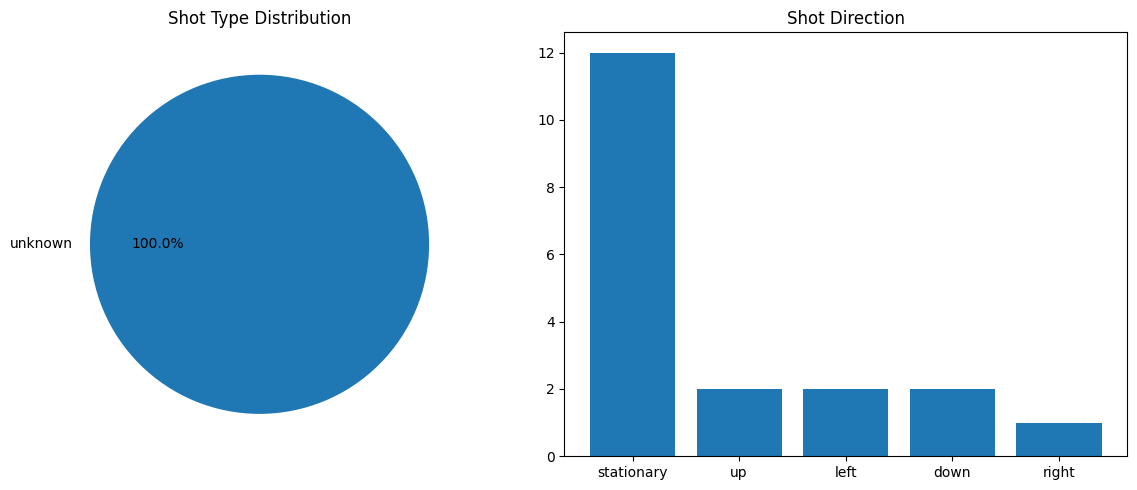

Dashboard saved to /kaggle/working/padel_pipeline/analytics/dashboard.png


In [17]:
# %% [markdown]
# ## 7. Dashboard (optional quick matplotlib)

# %% [code]
if shots_log:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Shot type pie chart
    shot_types = list(shot_counts.keys())
    shot_values = list(shot_counts.values())
    axes[0].pie(shot_values, labels=shot_types, autopct='%1.1f%%')
    axes[0].set_title("Shot Type Distribution")
    
    # Direction bar
    dirs = list(direction_counts.keys())
    dir_vals = list(direction_counts.values())
    axes[1].bar(dirs, dir_vals)
    axes[1].set_title("Shot Direction")
    
    plt.tight_layout()
    dashboard_path = ANALYTICS_DIR / "dashboard.png"
    plt.savefig(str(dashboard_path))
    plt.show()
    print(f"Dashboard saved to {dashboard_path}")